# SCENIC+ downstream analysis

appearantly some minor differences between the Celltype annotation of the GEX and ACC caused some problems here... but should work well enough to continue.

In [1]:
import dill
import scanpy as sc
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import pyranges
# Set stderr to null to avoid strange messages from ray
import sys
_stderr = sys.stderr
null = open(os.devnull,'wb')
work_dir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/mesoderm/'
tmp_dir = '/home/bt392/ry/'


## Downstream Analysis

In [2]:
scplus_obj = dill.load(open(os.path.join(work_dir, 'scenicplus/scplus_obj.pkl'), 'rb'))

In [3]:
scplus_obj.metadata_cell['GEX_celltype'] = scplus_obj.metadata_cell['ACC_celltype.mapped']

In [4]:
scplus_obj.metadata_regions.head()

,Chromosome,Start,End,Width,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc
chr1:3035602-3036202,chr1,3035602,3036202,600,1802,3.255755,945,2.975432
chr1:3062653-3063253,chr1,3062653,3063253,600,2962,3.471585,1499,3.175802
chr1:3072313-3072913,chr1,3072313,3072913,600,1773,3.248709,888,2.948413
chr1:3191496-3192096,chr1,3191496,3192096,600,4035,3.605844,2338,3.368845
chr1:3340575-3341175,chr1,3340575,3341175,600,1507,3.178113,826,2.916980


In [5]:
scplus_obj.uns['eRegulon_metadata'].head()

,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho
0,Alx1_+_+_(143r),Alx1_+_+_(76g),Alx1,False,chr11:96344507-96345107,Hoxb1,0.018433,0.386838,0.007131,0.007131,1.982993,1,0.050022,0.099193,0.099193
1,Alx1_+_+_(143r),Alx1_+_+_(76g),Alx1,False,chr11:96340900-96341500,Hoxb1,0.014224,0.345513,0.004914,0.004914,1.982993,1,0.050022,0.099193,0.099193
2,Alx1_+_+_(143r),Alx1_+_+_(76g),Alx1,False,chr11:96319141-96319741,Hoxb1,0.009437,0.358973,0.003388,0.003388,1.982993,1,0.050022,0.099193,0.099193
3,Alx1_+_+_(143r),Alx1_+_+_(76g),Alx1,False,chr11:96334783-96335383,Hoxb1,0.021290,0.399050,0.008496,0.008496,1.982993,1,0.050022,0.099193,0.099193
4,Alx1_+_+_(143r),Alx1_+_+_(76g),Alx1,False,chr11:96266606-96267206,Hoxb1,0.028511,0.323080,0.009211,0.009211,1.982993,1,0.050022,0.099193,0.099193


In [6]:
from scenicplus.preprocessing.filtering import apply_std_filtering_to_eRegulons
apply_std_filtering_to_eRegulons(scplus_obj)

Only keeping positive R2G
Only keep extended if not direct
Getting signatures...
Simplifying eRegulons ...


In [7]:
scplus_obj.uns['eRegulon_metadata_filtered'].head()

,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
0,Alx1_+_(143r),Alx1_+_(76g),Alx1,False,chr11:96344507-96345107,Hoxb1,0.018433,0.386838,0.007131,0.007131,1.982993,1,0.050022,0.099193,0.099193,Alx1_+_+
1,Alx1_+_(143r),Alx1_+_(76g),Alx1,False,chr11:96340900-96341500,Hoxb1,0.014224,0.345513,0.004914,0.004914,1.982993,1,0.050022,0.099193,0.099193,Alx1_+_+
2,Alx1_+_(143r),Alx1_+_(76g),Alx1,False,chr11:96319141-96319741,Hoxb1,0.009437,0.358973,0.003388,0.003388,1.982993,1,0.050022,0.099193,0.099193,Alx1_+_+
3,Alx1_+_(143r),Alx1_+_(76g),Alx1,False,chr11:96334783-96335383,Hoxb1,0.021290,0.399050,0.008496,0.008496,1.982993,1,0.050022,0.099193,0.099193,Alx1_+_+
4,Alx1_+_(143r),Alx1_+_(76g),Alx1,False,chr11:96266606-96267206,Hoxb1,0.028511,0.323080,0.009211,0.009211,1.982993,1,0.050022,0.099193,0.099193,Alx1_+_+


In [8]:
scplus_obj.uns['eRegulon_metadata_filtered'].to_csv(os.path.join(work_dir, 'scenicplus/eRegulon_metadata_filtered.csv'))

In [ ]:
from scenicplus.eregulon_enrichment import score_eRegulons
region_ranking = dill.load(open(os.path.join(work_dir, 'scenicplus/region_ranking.pkl'), 'rb')) #load ranking calculated using the wrapper function
gene_ranking = dill.load(open(os.path.join(work_dir, 'scenicplus/gene_ranking.pkl'), 'rb')) #load ranking calculated using the wrapper function
score_eRegulons(scplus_obj,
                ranking = region_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type= 'region',
                auc_threshold = 0.05,
                normalize = False,
                n_cpu = 30)
score_eRegulons(scplus_obj,
                gene_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type = 'gene',
                auc_threshold = 0.05,
                normalize= False,
                n_cpu = 30)

In [ ]:
from scenicplus.dimensionality_reduction import run_eRegulons_tsne, run_eRegulons_umap
run_eRegulons_umap(
    scplus_obj = scplus_obj,
    auc_key = 'eRegulon_AUC_filtered',
    reduction_name = 'eRegulons_UMAP', #overwrite previously calculated UMAP
)
run_eRegulons_tsne(
    scplus_obj = scplus_obj,
    auc_key = 'eRegulon_AUC_filtered',
    reduction_name = 'eRegulons_tSNE', #overwrite previously calculated tSNE
)

In [ ]:
from scenicplus.dimensionality_reduction import plot_metadata_given_ax
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#specify color_dictionary

color_dict = {
	"Epiblast" : "#635547",
	"Primitive_Streak" : "#DABE99",
	"Caudal_epiblast" : "#9e6762",
	"PGC" : "#FACB12",
	"Anterior_Primitive_Streak" : "#c19f70",
	"Notochord" : "#0F4A9C",
	"Def._endoderm" : "#F397C0",
	"Gut" : "#EF5A9D",
	"Nascent_mesoderm" : "#C594BF",
	"Mixed_mesoderm" : "#DFCDE4",
	"Intermediate_mesoderm" : "#139992",
	"Caudal_Mesoderm" : "#3F84AA",
	"Paraxial_mesoderm" : "#8DB5CE",
	"Somitic_mesoderm" : "#005579",
	"Pharyngeal_mesoderm" : "#C9EBFB",
	"Cardiomyocytes" : "#B51D8D",
	"Allantois" : "#532C8A",
	"ExE_mesoderm" : "#8870ad",
	"Mesenchyme" : "#cc7818",
	"Haematoendothelial_progenitors" : "#FBBE92",
	"Endothelium" : "#ff891c",
	"Blood_progenitors" : "#c9a997",
	"Blood_progenitors_1" : "#f9decf",
	"Blood_progenitors_2" : "#c9a997",
	"Erythroid" : "#EF4E22",
	"Erythroid1" : "#C72228",
	"Erythroid2" : "#f79083",
	"Erythroid3" : "#EF4E22",
	"NMP" : "#8EC792",
	"Neurectoderm" : "#65A83E",
	"Rostral_neurectoderm" : "#65A83E",
	"Caudal_neurectoderm" : "#354E23",
	"Neural_crest" : "#C3C388",
	"Forebrain_Midbrain_Hindbrain" : "#647a4f",
	"Spinal_cord" : "#CDE088",
	"Surface_ectoderm" : "#f7f79e",
	"Visceral_endoderm" : "#F6BFCB",
	"ExE_endoderm" : "#7F6874",
	"ExE_ectoderm" : "#989898",
	"Parietal_endoderm" : "#1A1A1A"
}

fig, axs = plt.subplots(ncols=2, figsize = (16, 8))
plot_metadata_given_ax(
    scplus_obj=scplus_obj,
    ax = axs[0],
    reduction_name = 'eRegulons_UMAP',
    variable = 'GEX_celltype', #note the GEX_ prefix, this metadata originated from the gene expression metadata (on which we did the cell type annotation before)
    color_dictionary={'GEX_celltype': color_dict}
)
plot_metadata_given_ax(
    scplus_obj=scplus_obj,
    ax = axs[1],
    reduction_name = 'eRegulons_tSNE',
    variable = 'GEX_celltype', #note the GEX_ prefix, this metadata originated from the gene expression metadata (on which we did the cell type annotation before)
    color_dictionary={'GEX_celltype': color_dict}
)
fig.tight_layout()
sns.despine(ax = axs[0]) #remove top and right edge of axis border
sns.despine(ax = axs[1]) #remove top and right edge of axis border
plt.show()

In [ ]:
from scenicplus.dimensionality_reduction import plot_metadata_given_ax
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#specify color_dictionary

color_dict = {
	'E7.5':"#440154FF",
	'E7.75':"#E6F598",
	'E8.0':"#31688EFF",
	'E8.5':"#35B779FF",
	'E8.75':"#FDE725FF"
}

fig, axs = plt.subplots(ncols=2, figsize = (16, 8))
plot_metadata_given_ax(
    scplus_obj=scplus_obj,
    ax = axs[0],
    reduction_name = 'eRegulons_UMAP',
    variable = 'GEX_stage', #note the GEX_ prefix, this metadata originated from the gene expression metadata (on which we did the cell type annotation before)
    color_dictionary={'GEX_stage': color_dict}
)
plot_metadata_given_ax(
    scplus_obj=scplus_obj,
    ax = axs[1],
    reduction_name = 'eRegulons_tSNE',
    variable = 'GEX_stage', #note the GEX_ prefix, this metadata originated from the gene expression metadata (on which we did the cell type annotation before)
    color_dictionary={'GEX_stage': color_dict}
)
fig.tight_layout()
sns.despine(ax = axs[0]) #remove top and right edge of axis border
sns.despine(ax = axs[1]) #remove top and right edge of axis border
plt.show()

In [ ]:
from scenicplus.dimensionality_reduction import plot_eRegulon
plot_eRegulon(
    scplus_obj = scplus_obj,
    reduction_name = 'eRegulons_UMAP',
    selected_regulons = ['Eomes_+', 'Gata1_+', 'Gata2_+', 'CEBPA_+', 'Runx1_+'],
    scale = True,
    auc_key = 'eRegulon_AUC_filtered')

### Filtering

In [17]:
from scenicplus.cistromes import TF_cistrome_correlation, generate_pseudobulks

generate_pseudobulks(
        scplus_obj = scplus_obj,
        variable = 'GEX_celltype',
        auc_key = 'eRegulon_AUC_filtered',
        signature_key = 'Gene_based')
generate_pseudobulks(
        scplus_obj = scplus_obj,
        variable = 'GEX_celltype',
        auc_key = 'eRegulon_AUC_filtered',
        signature_key = 'Region_based')

TF_cistrome_correlation(
            scplus_obj,
            use_pseudobulk = True,
            variable = 'GEX_celltype',
            auc_key = 'eRegulon_AUC_filtered',
            signature_key = 'Gene_based',
            out_key = 'filtered_gene_based')
TF_cistrome_correlation(
            scplus_obj,
            use_pseudobulk = True,
            variable = 'GEX_celltype',
            auc_key = 'eRegulon_AUC_filtered',
            signature_key = 'Region_based',
            out_key = 'filtered_region_based')

In [18]:
scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based'].head()

,TF,Cistrome,Rho,P-value,Adjusted_p-value
0,Foxh1,Foxh1_+_(36r),0.078605,3.249888e-03,3.774810e-03
1,Ebf1,Ebf1_extended_+_(329r),0.432351,7.452744e-65,1.822196e-64
2,Zfp41,Zfp41_+_(47r),0.195835,1.439750e-13,2.159626e-13
3,Arnt,Arnt_+_(289r),0.236852,2.649545e-19,4.406897e-19
4,Klf12,Klf12_extended_-_(348r),-0.809648,0.000000e+00,0.000000e+00


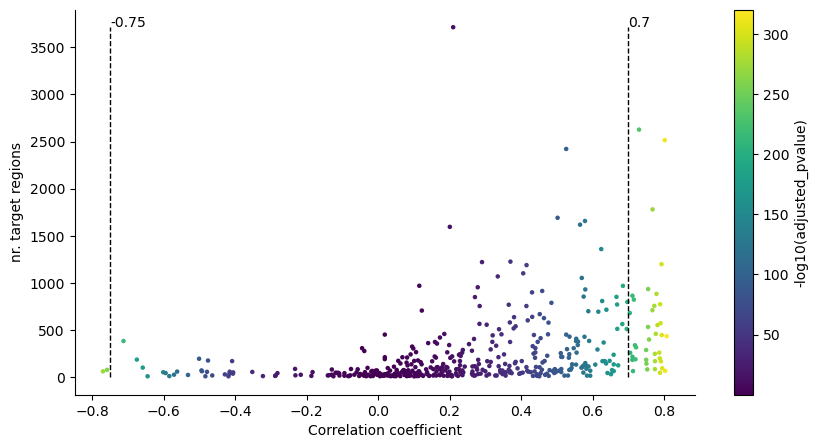

In [19]:
import numpy as np
n_targets = [int(x.split('(')[1].replace('r)', '')) for x in scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Cistrome']]
rho = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'].to_list()
adj_pval = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Adjusted_p-value'].to_list()

thresholds = {
        'rho': [-0.75, 0.70],
        'n_targets': 0
}
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5))
sc = ax.scatter(rho, n_targets, c = -np.log10(adj_pval), s = 5)
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('nr. target regions')
#ax.hlines(y = thresholds['n_targets'], xmin = min(rho), xmax = max(rho), color = 'black', ls = 'dashed', lw = 1)
ax.vlines(x = thresholds['rho'], ymin = 0, ymax = max(n_targets), color = 'black', ls = 'dashed', lw = 1)
ax.text(x = thresholds['rho'][0], y = max(n_targets), s = str(thresholds['rho'][0]))
ax.text(x = thresholds['rho'][1], y = max(n_targets), s = str(thresholds['rho'][1]))
sns.despine(ax = ax)
fig.colorbar(sc, label = '-log10(adjusted_pvalue)', ax = ax)
plt.show()

In [20]:
selected_cistromes = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based'].loc[
        np.logical_or(
                scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'] > thresholds['rho'][1],
                scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'] < thresholds['rho'][0]
        )]['Cistrome'].to_list()
selected_eRegulons = [x.split('_(')[0] for x in selected_cistromes]
selected_eRegulons_gene_sig = [
        x for x in scplus_obj.uns['eRegulon_signatures_filtered']['Gene_based'].keys()
        if x.split('_(')[0] in selected_eRegulons]
selected_eRegulons_region_sig = [
        x for x in scplus_obj.uns['eRegulon_signatures_filtered']['Region_based'].keys()
        if x.split('_(')[0] in selected_eRegulons]
#save the results in the scenicplus object
scplus_obj.uns['selected_eRegulon'] = {'Gene_based': selected_eRegulons_gene_sig, 'Region_based': selected_eRegulons_region_sig}
print(f'selected: {len(selected_eRegulons_gene_sig)} eRegulons')

selected: 78 eRegulons


In [99]:
pd.DataFrame(scplus_obj.uns['selected_eRegulon']['Gene_based']).to_csv(os.path.join(work_dir, 'scenicplus/eRegulon_to_keep.csv'), header=True, index=False)

In [100]:
dill.dump(scplus_obj, open(os.path.join(work_dir, 'scenicplus/scplus_obj_filt.pkl'), 'wb'), protocol=-1)

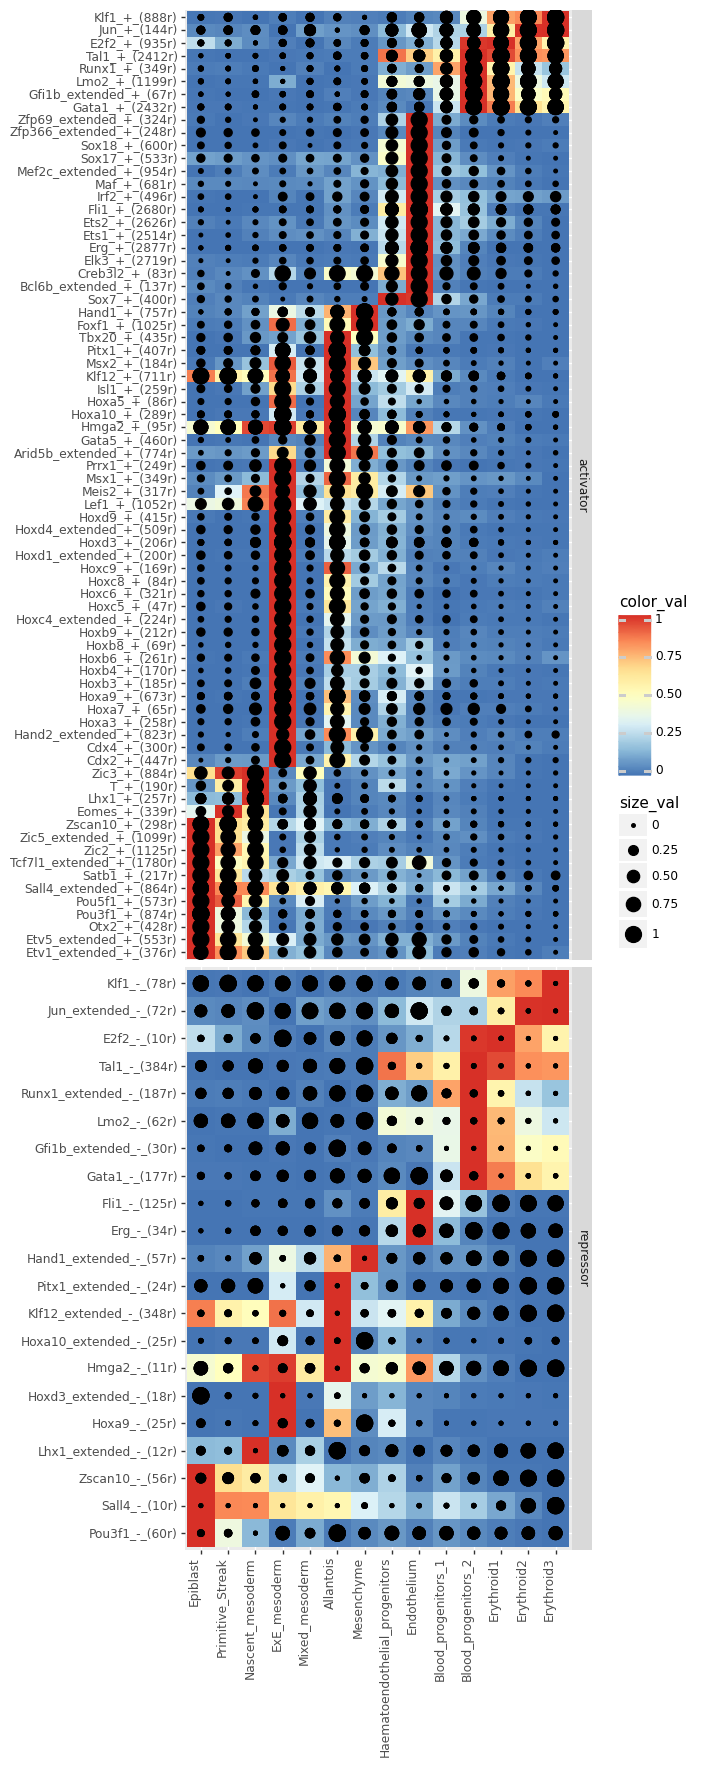

<ggplot: (2958846775056)>

In [23]:
from scenicplus.plotting.dotplot import heatmap_dotplot
heatmap_dotplot(
        scplus_obj = scplus_obj,
        size_matrix = scplus_obj.uns['eRegulon_AUC_filtered']['Region_based'], #specify what to plot as dot sizes, target region enrichment in this case
        color_matrix = scplus_obj.to_df('EXP'), #specify  what to plot as colors, TF expression in this case
        scale_size_matrix = True,
        scale_color_matrix = True,
        group_variable = 'GEX_celltype',
        subset_eRegulons = scplus_obj.uns['selected_eRegulon']['Gene_based'],
        index_order = ["Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "ExE_mesoderm",
                        "Mixed_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3"],
        figsize = (5, 20),
        orientation = 'vertical')

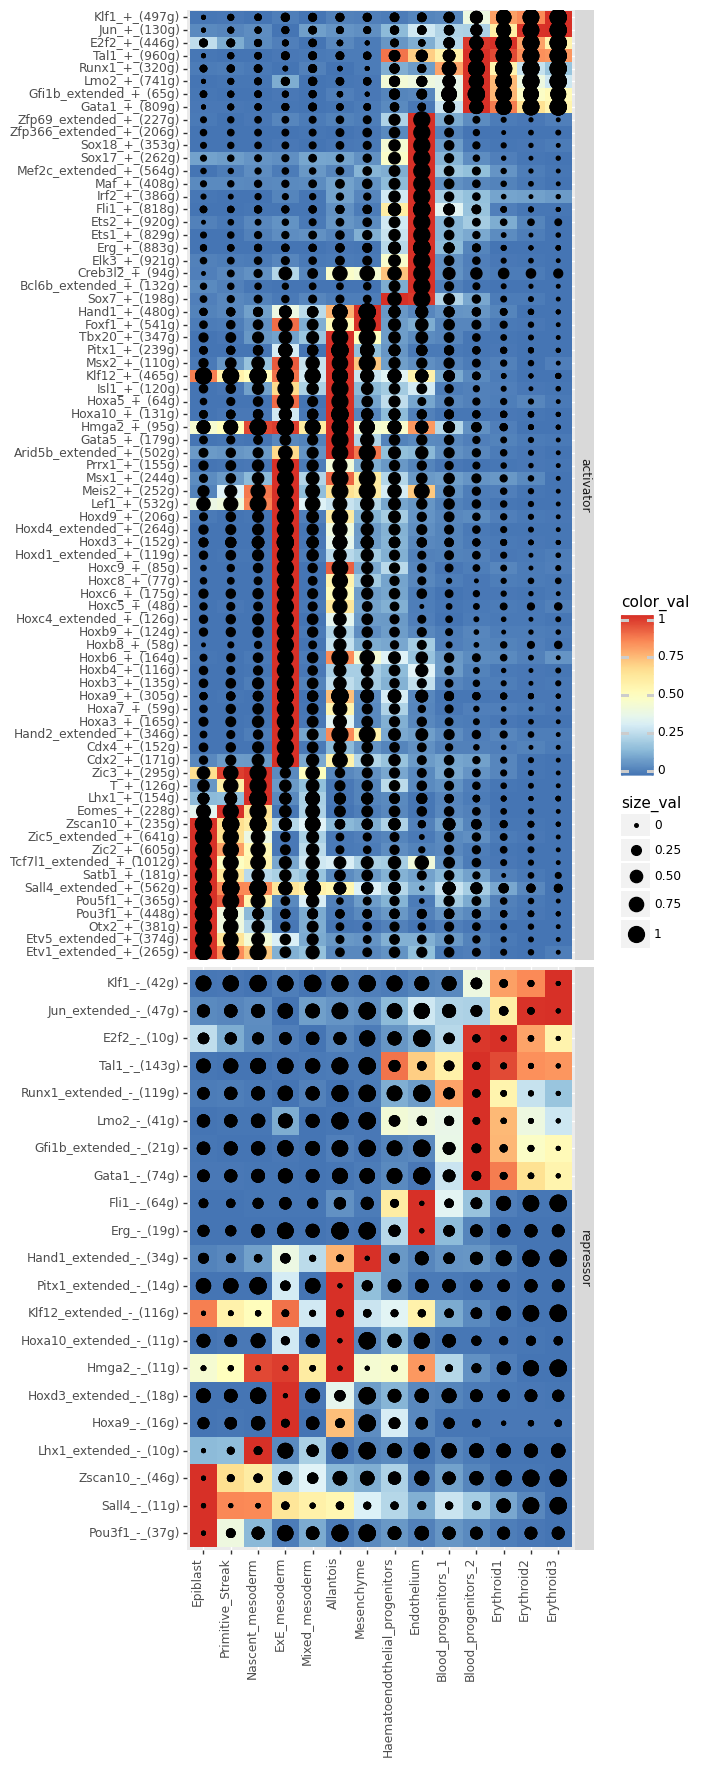

<ggplot: (2958848406679)>

In [24]:
from scenicplus.plotting.dotplot import heatmap_dotplot
heatmap_dotplot(
        scplus_obj = scplus_obj,
        size_matrix = scplus_obj.uns['eRegulon_AUC_filtered']['Gene_based'], #specify what to plot as dot sizes, target region enrichment in this case
        color_matrix = scplus_obj.to_df('EXP'), #specify  what to plot as colors, TF expression in this case
        scale_size_matrix = True,
        scale_color_matrix = True,
        group_variable = 'GEX_celltype',
        subset_eRegulons = scplus_obj.uns['selected_eRegulon']['Gene_based'],
        index_order = ["Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "ExE_mesoderm",
                        "Mixed_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3"],
        figsize = (5, 20),
        orientation = 'vertical')

In [25]:
from scenicplus.RSS import *
regulon_specificity_scores(
        scplus_obj,
        variable = 'GEX_celltype',
        auc_key = 'eRegulon_AUC_filtered',
        signature_keys = ['Region_based'],
        selected_regulons = [x for x in scplus_obj.uns['selected_eRegulon']['Region_based'] if '-' not in x],
        out_key_suffix = '_filtered')

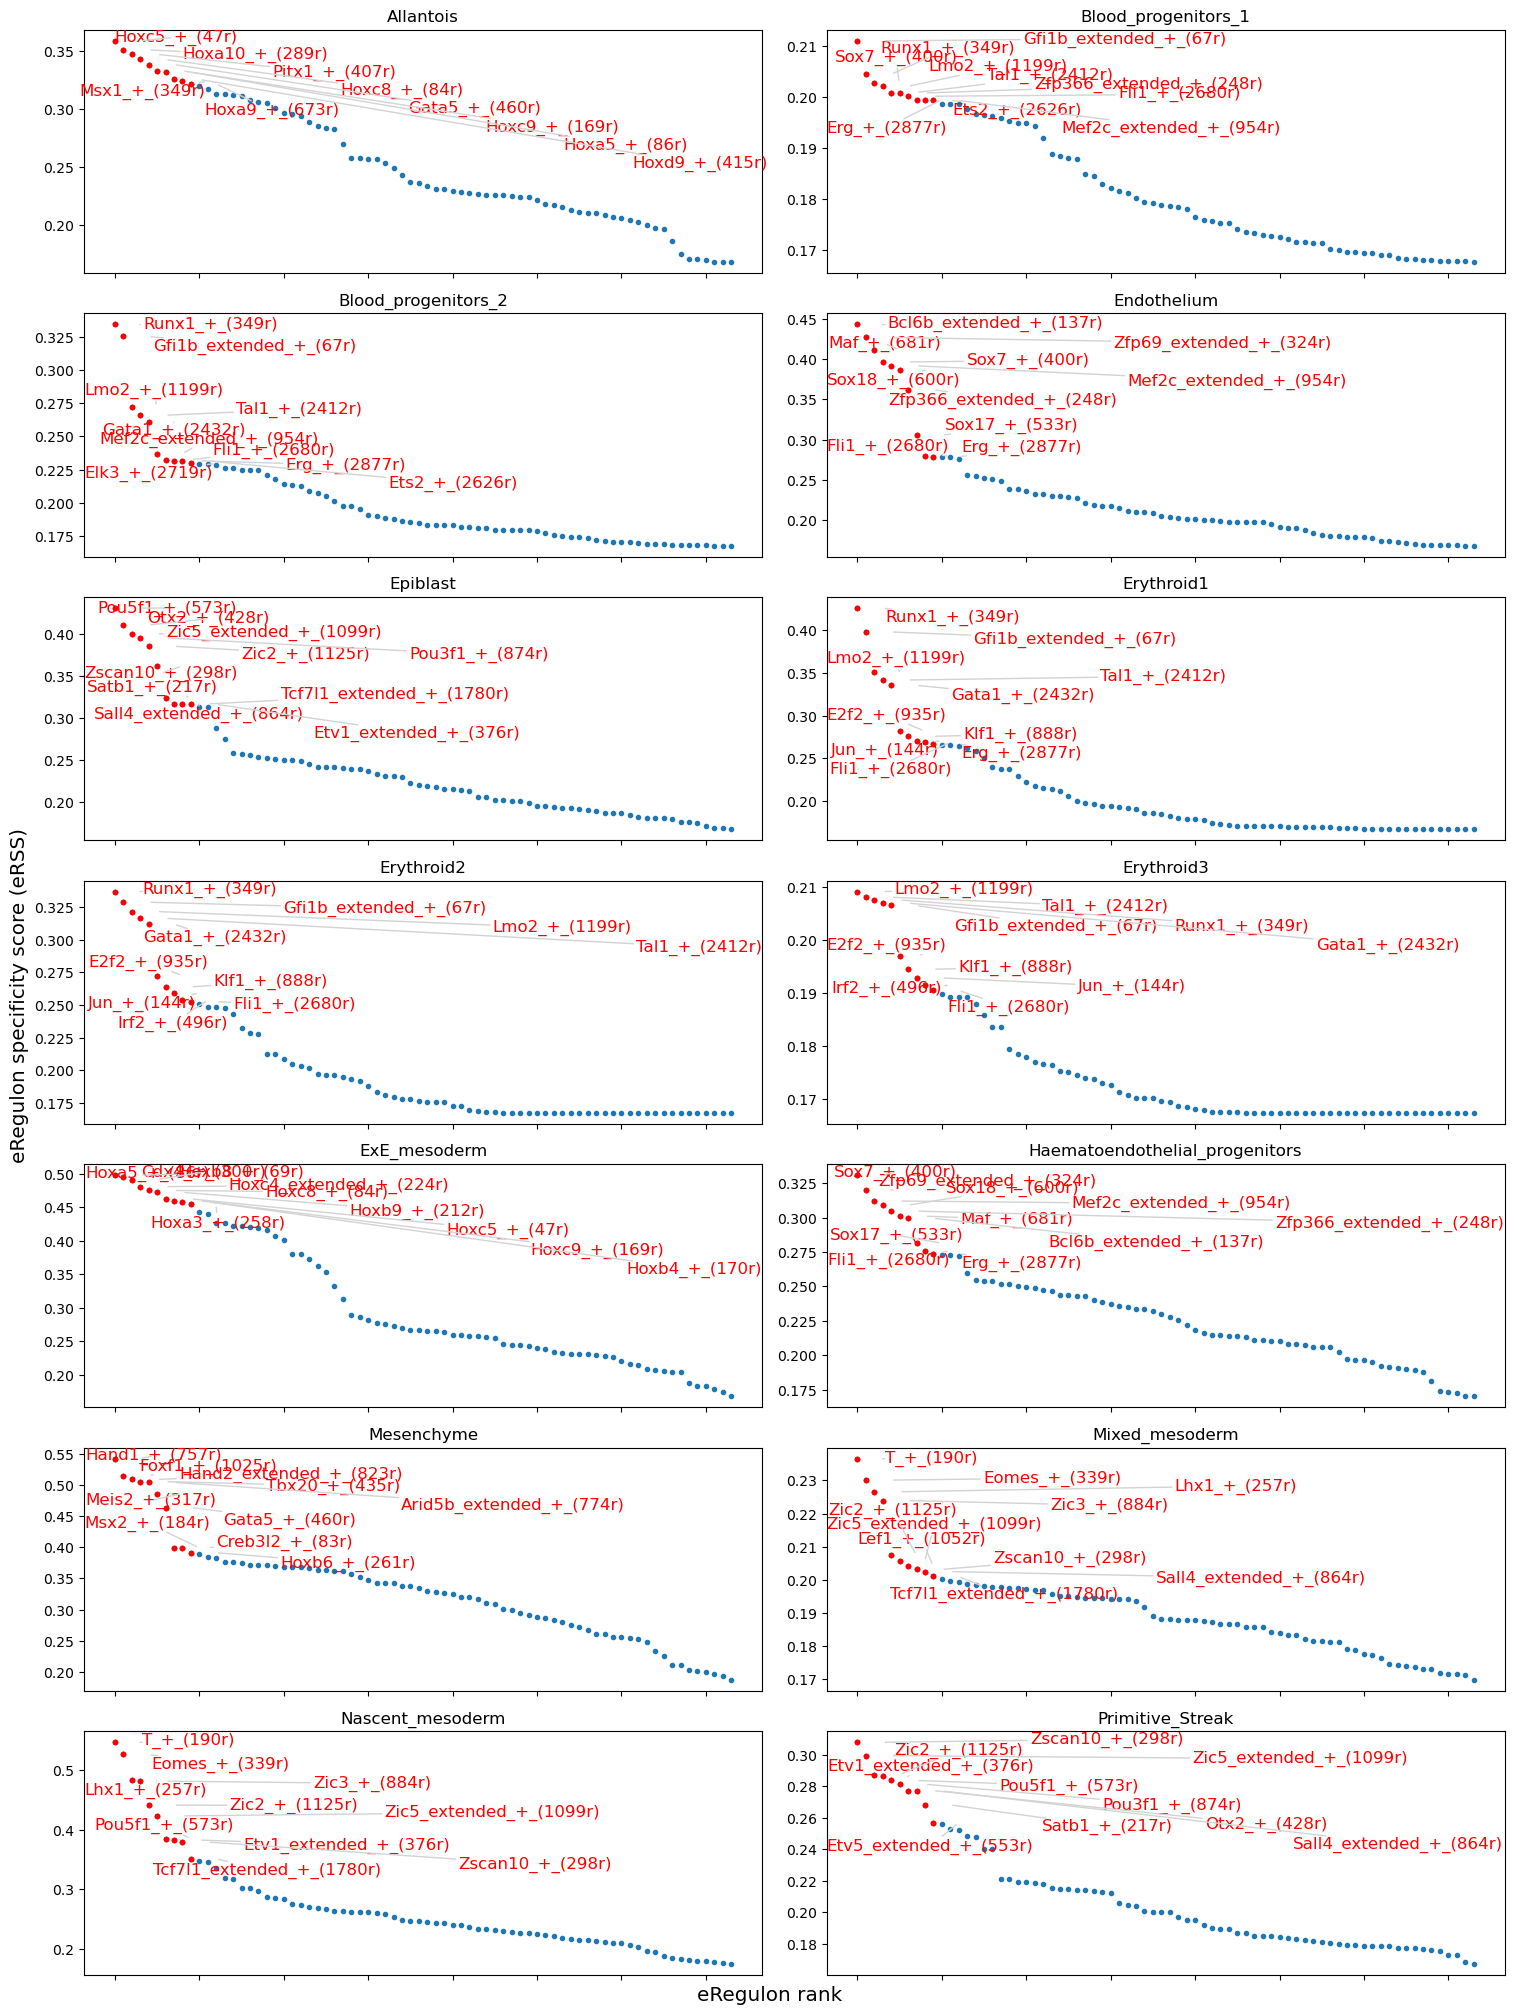

In [28]:
plot_rss(scplus_obj, 'GEX_celltype_filtered', num_columns=2, top_n=10, figsize = (15, 20))

In [29]:
flat_list = lambda t: [item for sublist in t for item in sublist]
selected_markers = list(set(flat_list(
    [scplus_obj.uns['RSS']['GEX_celltype_filtered'].loc[celltype].sort_values(ascending = False).head(10).index.to_list()
    for celltype in scplus_obj.uns['RSS']['GEX_celltype_filtered'].index])))

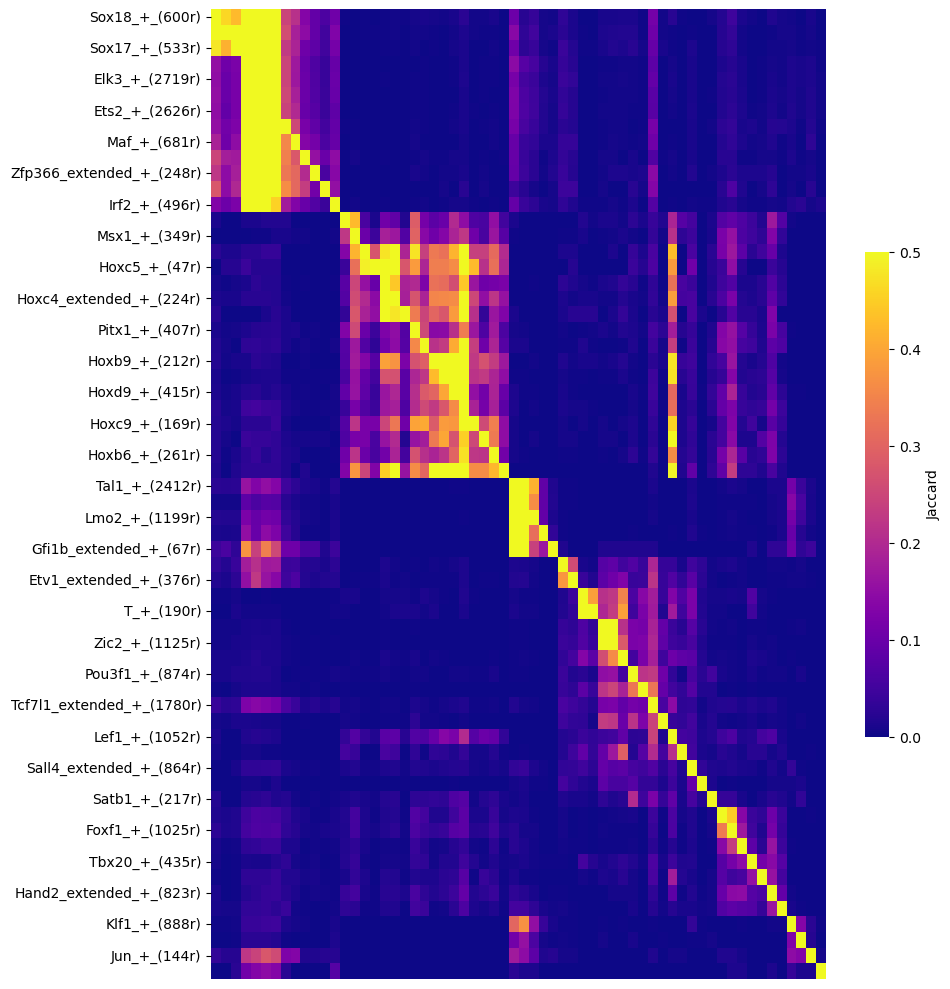

In [30]:
from scenicplus.plotting.correlation_plot import *

region_intersetc_data, Z = jaccard_heatmap(
        scplus_obj,
        method = 'intersect',
        gene_or_region_based = 'Region_based',
        use_plotly = False,
        selected_regulons = selected_markers,
        signature_key = 'eRegulon_signatures_filtered',
        figsize = (10, 10), return_data = True, vmax = 0.5, cmap = 'plasma')

In [126]:
jaccard_heatmap(scplus_obj,
                    gene_or_region_based = 'Gene_based',
                    signature_key = 'eRegulon_signatures',
                    selected_regulons = scplus_obj.uns['selected_eRegulon']['Gene_based'],
                    fcluster_threshold = 0.1,
                    fontsize = 3,
                    method='intersect')

KeyError: 'eRegulon_signature'

In [31]:
from pycisTopic.diff_features import find_highly_variable_features
hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['eRegulon_metadata_filtered']['Region']))], n_top_features=1000, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['eRegulon_metadata_filtered']['Gene']))].T, n_top_features=1000, plot = False)

2022-08-29 09:23:18,466 cisTopic     INFO     Calculating mean
2022-08-29 09:23:18,735 cisTopic     INFO     Calculating variance
2022-08-29 09:23:21,343 cisTopic     INFO     Done!
2022-08-29 09:23:21,564 cisTopic     INFO     Calculating mean
2022-08-29 09:23:21,621 cisTopic     INFO     Calculating variance
2022-08-29 09:23:22,016 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Network!

In [117]:
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
nx_tables = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata_filtered',
    subset_eRegulons = ['Gata1', 'Gata2', 'Tal1', 'Runx1'],
    subset_regions = hvr,
    subset_genes = hvg,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = ['GEX_celltype'])

... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical


In [118]:
G, pos, edge_tables, node_tables = create_nx_graph(nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'Gata1': 'Orange', 'Gata2': 'Purple', 'Tal1': 'Red', 'Runx1': 'Green'}},
                                    'R2G': {'variable' : 'R2G_rho', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'R2G_importance', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'R2G_importance', 'max_size' :  1.5, 'min_size' : 1}},
                   color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'Gata1': 'Orange', 'Gata2': 'Purple', 'Tal1': 'Red', 'Runx1': 'Green'}},
                                    'Gene': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'bwr'},
                                    'Region': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'viridis'}},
                   transparency_node_by =  {'Region': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1},
                                    'Gene': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='kamada_kawai_layout',
                   scale_position_by=250)

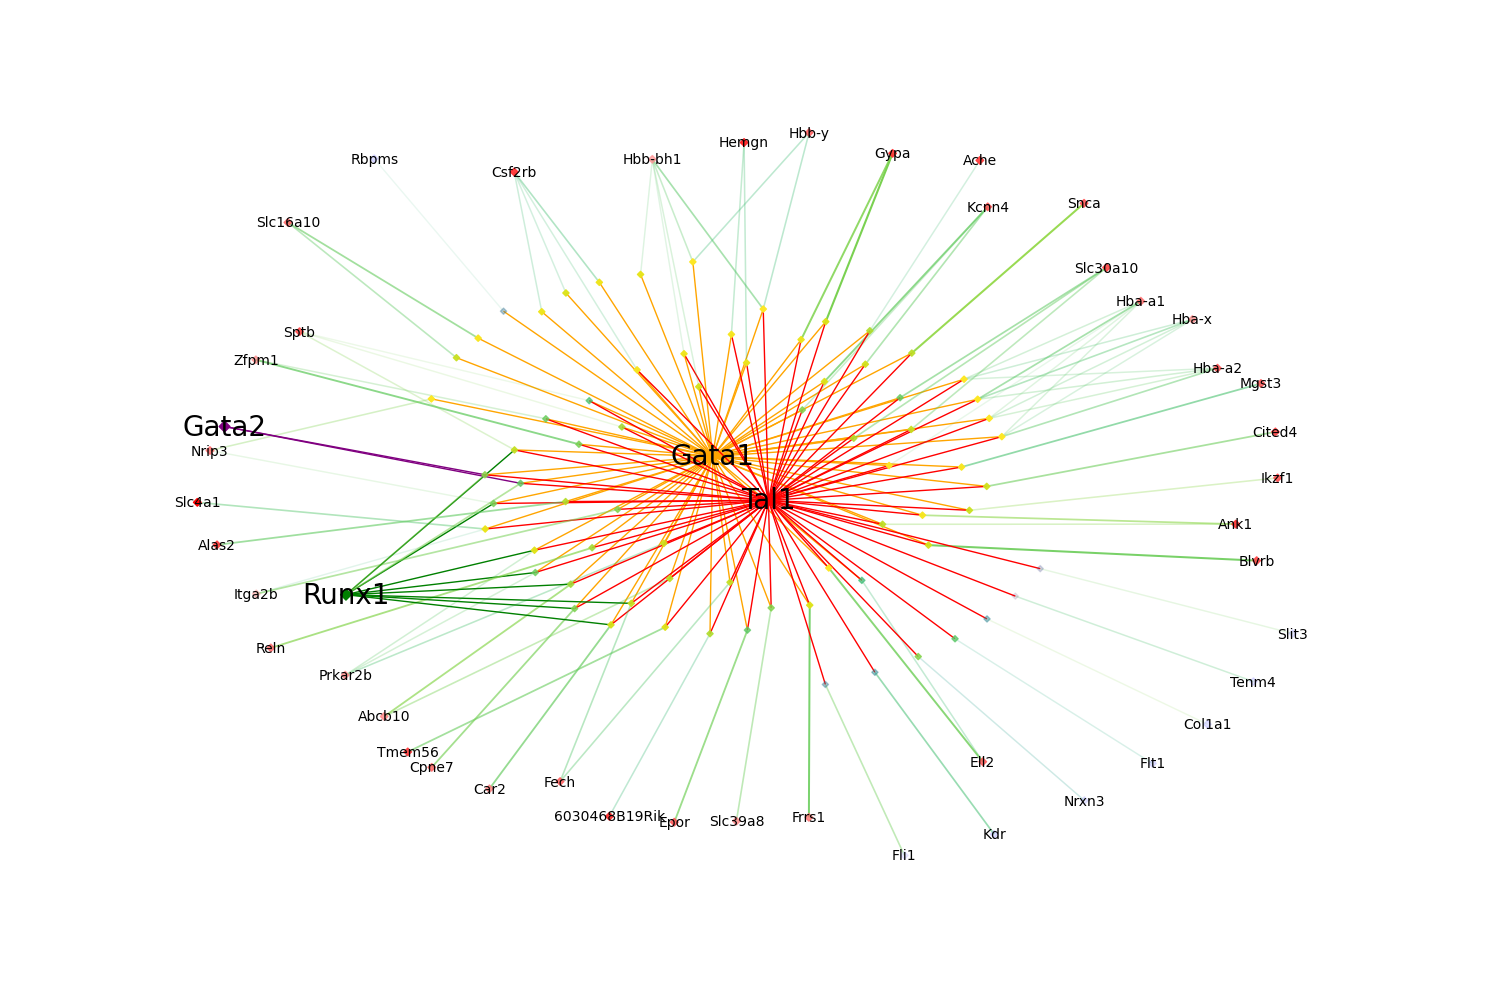

In [119]:
plt.figure(figsize=(15,10))
plot_networkx(G, pos)

In [139]:
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
nx_tables = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata_filtered',
    subset_eRegulons = ['Gata1', 'Tal1', 'Runx1', 'Gfi1b', 'Lmo2', 'E2f2', 'Klf1', 'Erg', 'Fli1', 'Jun'],
    subset_regions = hvr,
    subset_genes = hvg,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = ['GEX_celltype'])

G, pos, edge_tables, node_tables = create_nx_graph(nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'Gata1': 'Orange', 'Tal1': 'Purple', 'Runx1': 'Red', 'Gfi1b': 'Green',
                                                                                   'Lmo2': 'Yellow', 'E2f2': 'Aqua', 'Klf1': 'Violet', 'Erg': 'Gray', 'Fli1': 'Bisque', 'Jun': 'Darkgreen'}},
                                    'R2G': {'variable' : 'R2G_rho', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'R2G_importance', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'R2G_importance', 'max_size' :  1.5, 'min_size' : 1}},
                   color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'Gata1': 'Orange', 'Tal1': 'Purple', 'Runx1': 'Red', 'Gfi1b': 'Green',
                                                                                   'Lmo2': 'Yellow', 'E2f2': 'Aqua', 'Klf1': 'Violet', 'Erg': 'Gray', 'Fli1': 'Bisque', 'Jun': 'Darkgreen'}},
                                    'Gene': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'bwr'},
                                    'Region': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'viridis'}},
                   transparency_node_by =  {'Region': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1},
                                    'Gene': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='kamada_kawai_layout',
                   scale_position_by=600)

... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical


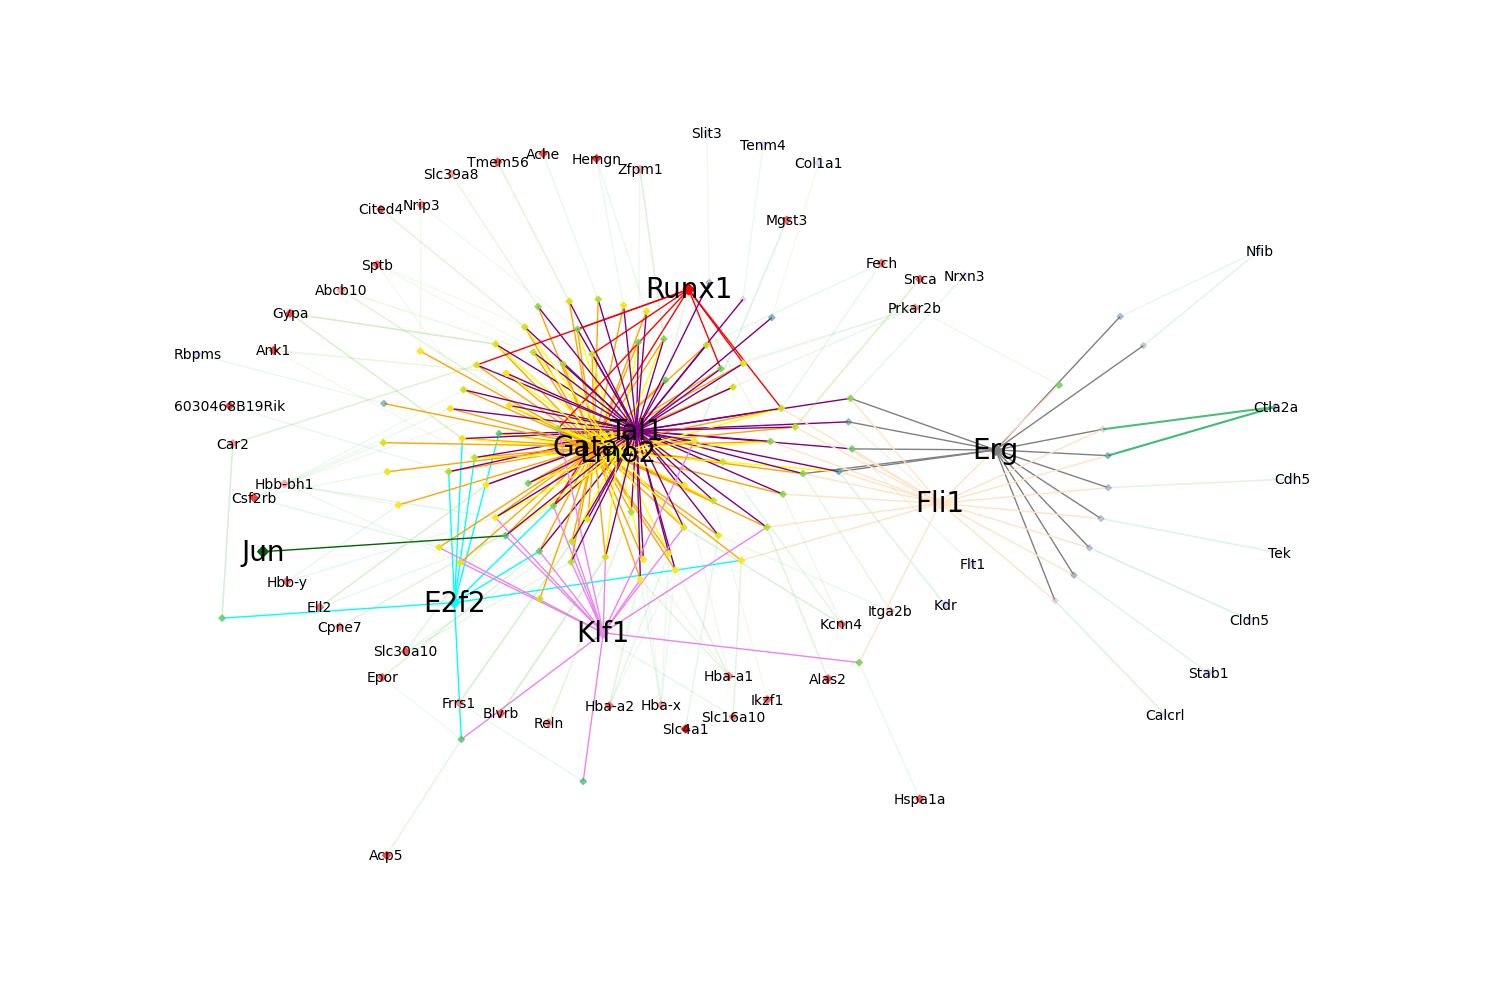

In [140]:
plt.figure(figsize=(15,10))
plot_networkx(G, pos)

In [145]:
export_to_cytoscape(G, pos, out_file = os.path.join(work_dir, 'scenicplus/network_Erythroid.cyjs'), pos_scaling_factor = 400, size_scaling_factor = 1)
## in cytoscape follow this: 
# Select Layout → Bundle Edges → All Nodes and Edges.
# Set parameters.
# Details of the algorithm is described in this paper.
# Press OK to run. Edge bundling may take a long time if the number of edges is large.
# If it takes too long, try decreasing Maximum Iterations.
# For large, dense networks, try setting Maximum iterations in the range of 500 - 1000.

In [155]:
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
nx_tables = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata_filtered_manual',
    subset_eRegulons = ['Gata1', 'Tal1', 'Runx1', 'Gfi1b', 'Lmo2', 'E2f2', 'Klf1', 'Erg', 'Fli1', 'Jun'],
  #  subset_regions = hvr,
  #  subset_genes = hvg,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = ['GEX_celltype'])

... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical


In [168]:
# Manual filtering
network = scplus_obj.uns['eRegulon_metadata_filtered'].copy()
network_filt = network.loc[(network['R2G_rho'] >= 0.25) & (network['TF2G_rho'] >= 0.25)]
scplus_obj.uns['eRegulon_metadata_filtered_manual'] = network_filt

In [175]:
nx_tables = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata_filtered_manual',
    subset_eRegulons = ['Gata1', 'Tal1', 'Runx1', 'Gfi1b', 'Lmo2', 'E2f2', 'Klf1', 'Erg', 'Fli1', 'Jun'],
#    subset_regions = hvr,
#    subset_genes = hvg,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = ['GEX_celltype'])

... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical
... storing 'GEX_celltype' as categorical


In [176]:

G, pos, edge_tables, node_tables = create_nx_graph(nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'Gata1': 'Orange', 'Tal1': 'Purple', 'Runx1': 'Red', 'Gfi1b': 'Green',
                                                                                   'Lmo2': 'Yellow', 'E2f2': 'Aqua', 'Klf1': 'Violet', 'Erg': 'Gray', 'Fli1': 'Bisque', 'Jun': 'Darkgreen'}},
                                    'R2G': {'variable' : 'R2G_rho', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'R2G_importance', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'R2G_importance', 'max_size' :  1.5, 'min_size' : 1}},
                   color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'Gata1': 'Orange', 'Tal1': 'Purple', 'Runx1': 'Red', 'Gfi1b': 'Green',
                                                                                   'Lmo2': 'Yellow', 'E2f2': 'Aqua', 'Klf1': 'Violet', 'Erg': 'Gray', 'Fli1': 'Bisque', 'Jun': 'Darkgreen'}},
                                    'Gene': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'bwr'},
                                    'Region': {'variable': 'GEX_celltype_Log2FC_Erythroid3', 'continuous_color' : 'viridis'}},
                   transparency_node_by =  {'Region': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1},
                                    'Gene': {'variable' : 'GEX_celltype_Log2FC_Erythroid3', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='kamada_kawai_layout',
                   scale_position_by=500)


In [177]:
export_to_cytoscape(G, pos, out_file = os.path.join(work_dir, 'scenicplus/network_Erythroid_big.cyjs'), pos_scaling_factor = 400, size_scaling_factor = 1)

In [265]:
network_filt = network.loc[(network['TF2G_rho'] >= 0.55)]
#vc = network_filt['TF'].value_counts()
#network_filt = network_filt[network_filt['TF'].isin(vc[vc >= 3].index)]. # keep only the ones that appear >= 3 times, doesn't work somehow
network_filt = network_filt.loc[(network_filt['TF'].isin(network_filt['Gene']))]
network_filt = network_filt.loc[(network_filt['Gene'].isin(network_filt['TF']))]
scplus_obj.uns['eRegulon_metadata_filtered_TFs'] = network_filt

In [294]:
nx_tables = create_nx_tables(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata_filtered_TFs',
  #  subset_eRegulons =  network_filt['TF'].unique().tolist(),
    subset_regions = hvr,
    subset_genes = hvg,
   # add_differential_gene_expression = True,
  #  add_differential_region_accessibility = True,
    differential_variable = ['GEX_celltype'])

In [297]:
def get_N_HexCol(N=5):
    HSV_tuples = [(x * 1.0 / N, 0.5, 0.5) for x in range(N)]
    hex_out = []
    for rgb in HSV_tuples:
        rgb = map(lambda x: int(x * 255), colorsys.hsv_to_rgb(*rgb))
        hex_out.append('#%02x%02x%02x' % tuple(rgb))
    return hex_out

In [298]:
colors = get_N_HexCol(N = len(network_filt['TF'].unique().tolist()))
TFs = network_filt['TF'].unique().tolist()

In [299]:
col_dict = {TFs[i]: colors[i] for i in range(len(TFs))}

In [302]:
nx_tables

{'Edge': {'TF2R':         TF                   Region Consensus_name Gene_signature_name  \
  230   Elk3   chr9:32582039-32582639       Elk3_+_+       Elk3_+_(921g)   
  305    Erg   chr9:32582039-32582639        Erg_+_+        Erg_+_(883g)   
  264   Fli1   chr9:32582039-32582639       Fli1_+_+       Fli1_+_(818g)   
  127  Runx1  chr16:92801439-92802039      Runx1_+_+      Runx1_+_(320g)   
  128  Runx1  chr16:92822085-92822685      Runx1_+_+      Runx1_+_(320g)   
  
      Region_signature_name is_extended  
  230        Elk3_+_(2719r)       False  
  305         Erg_+_(2877r)       False  
  264        Fli1_+_(2680r)       False  
  127        Runx1_+_(349r)       False  
  128        Runx1_+_(349r)       False  ,
  'R2G':                       Region   Gene Consensus_name Gene_signature_name  \
  230   chr9:32582039-32582639   Fli1       Elk3_+_+       Elk3_+_(921g)   
  305   chr9:32582039-32582639   Fli1        Erg_+_+        Erg_+_(883g)   
  264   chr9:32582039-32582639   Fli1

### Interactions

To-do, uses bigwig generated via pycistopic. also possible via ones from Archr?

In [ ]:
# # Generate interaction and annotation pyranges
# import matplotlib.pyplot as plt
# import os
# from scenicplus.utils import get_interaction_pr
# import pyranges as pr
# bigwig_dir = '/staging/leuven/stg_00002/lcb/cbravo/Multiomics_pipeline/analysis/10x_multiome_brain/output/atac/pycistopic/consensus_peak_calling/seurat_pseudobulk_bw_files/'
# bw_dict = {x.replace('.bw', ''): os.path.join(bigwig_dir, x) for x in os.listdir(bigwig_dir) if '.bw' in x}
# pr_consensus_bed = pr.read_bed('/staging/leuven/stg_00002/lcb/cbravo/Multiomics_pipeline/analysis/10x_multiome_brain/output/atac/pycistopic/consensus_peak_calling/consensus_regions.bed')
# pr_interact = get_interaction_pr(scplus_obj, 'hsapiens', 'hg38', inplace = False, subset_for_eRegulons_regions = True, eRegulons_key = 'eRegulons_importance')
# gtf_file = "/lustre1/project/stg_00002/lcb/fderop/data/00000000_genomes/GRCh38_STAR_2.7.5_rna/genes.gtf"
# pr_gtf = pr.read_gtf(gtf_file)

### Perturbation simulation

I think they may be ran on eRegulon_metadata rather than filtered version?

To-do:
run on filtered GRN
Run regression only once and then plot for all genes of interest

https://github.com/aertslab/scenicplus/blob/main/src/scenicplus/simulation.py
https://scenicplus.readthedocs.io/en/latest/Perturbation_simulation.html

In [47]:
from scenicplus.dimensionality_reduction import run_eRegulons_pca
run_eRegulons_pca(
        scplus_obj,
        auc_key = 'eRegulon_AUC_filtered',
        reduction_name = 'eRegulons_PCA_gene_based',
        selected_regulons = scplus_obj.uns['selected_eRegulon']['Gene_based'])

In [48]:
from pycisTopic.diff_features import find_highly_variable_features
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['eRegulon_metadata_filtered']['Gene']))].T, n_top_features = 200, plot = False)

2022-08-29 09:38:34,344 cisTopic     INFO     Calculating mean
2022-08-29 09:38:34,402 cisTopic     INFO     Calculating variance
2022-08-29 09:38:34,805 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

2022-08-29 09:52:57,392 perturbation INFO     Caclulating perturbation matrix for: {'Stat3': 0} over 5 iterations.


100%|██████████| 200/200 [05:01<00:00,  1.51s/it]


2022-08-29 10:00:38,046 perturbation INFO     Generating ranking based on perturbed matrix.
2022-08-29 10:01:23,039 perturbation INFO     Scoring eRegulons.
2022-08-29 10:01:40,115 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2022-08-29 10:02:05,838 perturbation INFO     Calculating grid of arrows
2022-08-29 10:02:05,932 perturbation INFO     Plotting


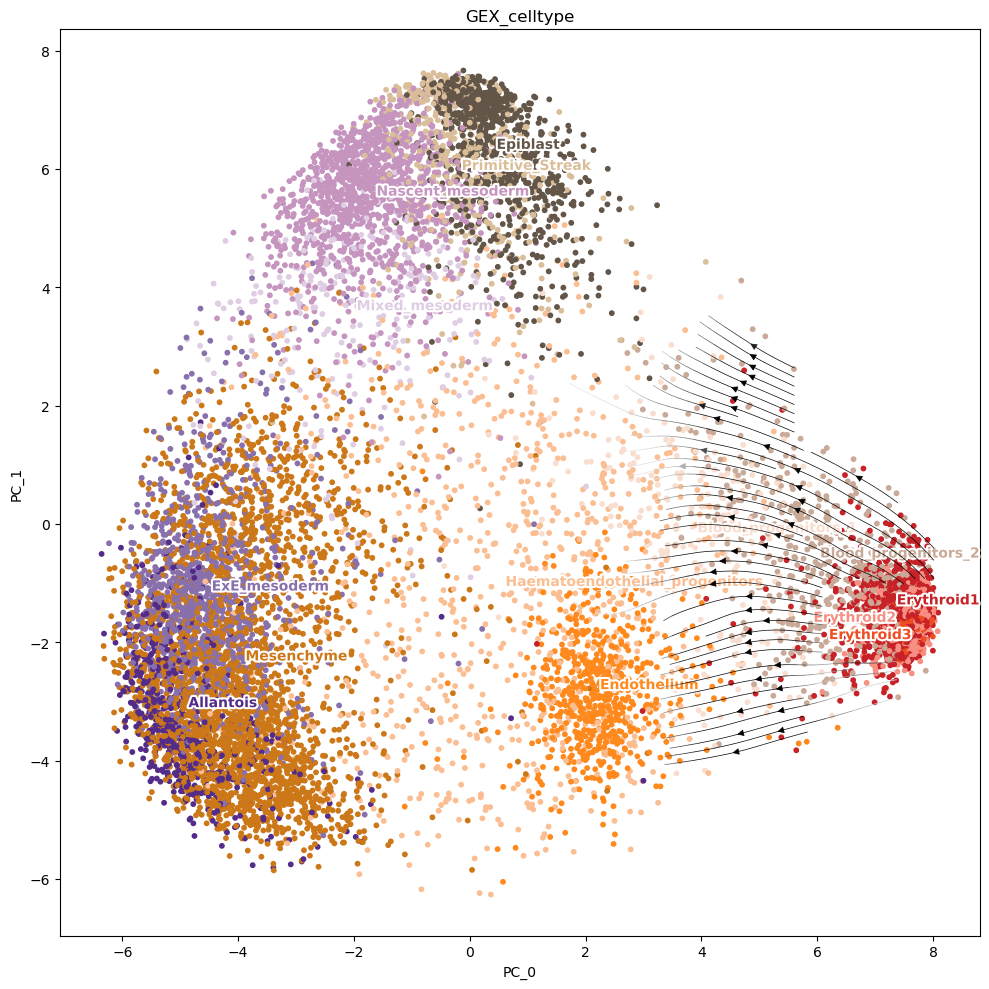

In [51]:
color_dict_line = {
   "Epiblast" : "#635547",
	"Primitive_Streak" : "#DABE99",
	"Caudal_epiblast" : "#9e6762",
	"PGC" : "#FACB12",
	"Anterior_Primitive_Streak" : "#c19f70",
	"Notochord" : "#0F4A9C",
	"Def._endoderm" : "#F397C0",
	"Gut" : "#EF5A9D",
	"Nascent_mesoderm" : "#C594BF",
	"Mixed_mesoderm" : "#DFCDE4",
	"Intermediate_mesoderm" : "#139992",
	"Caudal_Mesoderm" : "#3F84AA",
	"Paraxial_mesoderm" : "#8DB5CE",
	"Somitic_mesoderm" : "#005579",
	"Pharyngeal_mesoderm" : "#C9EBFB",
	"Cardiomyocytes" : "#B51D8D",
	"Allantois" : "#532C8A",
	"ExE_mesoderm" : "#8870ad",
	"Mesenchyme" : "#cc7818",
	"Haematoendothelial_progenitors" : "#FBBE92",
	"Endothelium" : "#ff891c",
	"Blood_progenitors" : "#c9a997",
	"Blood_progenitors_1" : "#f9decf",
	"Blood_progenitors_2" : "#c9a997",
	"Erythroid" : "#EF4E22",
	"Erythroid1" : "#C72228",
	"Erythroid2" : "#f79083",
	"Erythroid3" : "#EF4E22",
	"NMP" : "#8EC792",
	"Neurectoderm" : "#65A83E",
	"Rostral_neurectoderm" : "#65A83E",
	"Caudal_neurectoderm" : "#354E23",
	"Neural_crest" : "#C3C388",
	"Forebrain_Midbrain_Hindbrain" : "#647a4f",
	"Spinal_cord" : "#CDE088",
	"Surface_ectoderm" : "#f7f79e",
	"Visceral_endoderm" : "#F6BFCB",
	"ExE_endoderm" : "#7F6874",
	"ExE_ectoderm" : "#989898",
	"Parietal_endoderm" : "#1A1A1A"}

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
_ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_PCA_gene_based',
        n_cpu = 30,
        perturbation = {'Stat3': 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_celltype',
        color_dictionary = {'GEX_celltype': color_dict_line},
        genes_to_use = hvg,
        figsize = (10, 10))

In [52]:
scplus_obj

SCENIC+ object with n_cells x n_genes = 12686 x 32285 and n_cells x n_regions = 12686 x 120828
	metadata_regions:'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
	metadata_genes:'gene'
	metadata_cell:'GEX_barcode', 'GEX_sample', 'GEX_nFeature_RNA', 'GEX_nCount_RNA', 'GEX_mitochondrial_percent_RNA', 'GEX_ribosomal_percent_RNA', 'GEX_stage', 'GEX_genotype', 'GEX_pass_rnaQC', 'GEX_doublet_score', 'GEX_doublet_call', 'GEX_celltype', 'GEX_celltype.score', 'GEX_closest.cell', 'GEX_n_genes_by_counts', 'GEX_total_counts', 'GEX_total_counts_mt', 'GEX_pct_counts_mt', 'ACC_cisTopic_log_nr_acc', 'ACC_cisTopic_nr_frag', 'ACC_cisTopic_nr_acc', 'ACC_cell', 'ACC_sample_id', 'ACC_cisTopic_log_nr_frag', 'ACC_barcode', 'ACC_sample', 'ACC_nFeature_RNA', 'ACC_nCount_RNA', 'ACC_mitochondrial_percent_RNA', 'ACC_ribosomal_percent_RNA', 'ACC_stage', 'ACC_genotype', 'ACC_pass_rnaQC', 'ACC_doublet_score', 'ACC_doublet_call', 'ACC_celltype

2022-08-29 13:51:05,695 perturbation INFO     Caclulating perturbation matrix for: {'Stat3': 0} over 5 iterations.


100%|██████████| 200/200 [05:03<00:00,  1.52s/it]


2022-08-29 13:58:53,423 perturbation INFO     Generating ranking based on perturbed matrix.
2022-08-29 13:59:39,373 perturbation INFO     Scoring eRegulons.
2022-08-29 13:59:58,582 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_tSNE
2022-08-29 14:00:33,494 perturbation INFO     Calculating grid of arrows
2022-08-29 14:00:33,583 perturbation INFO     Plotting


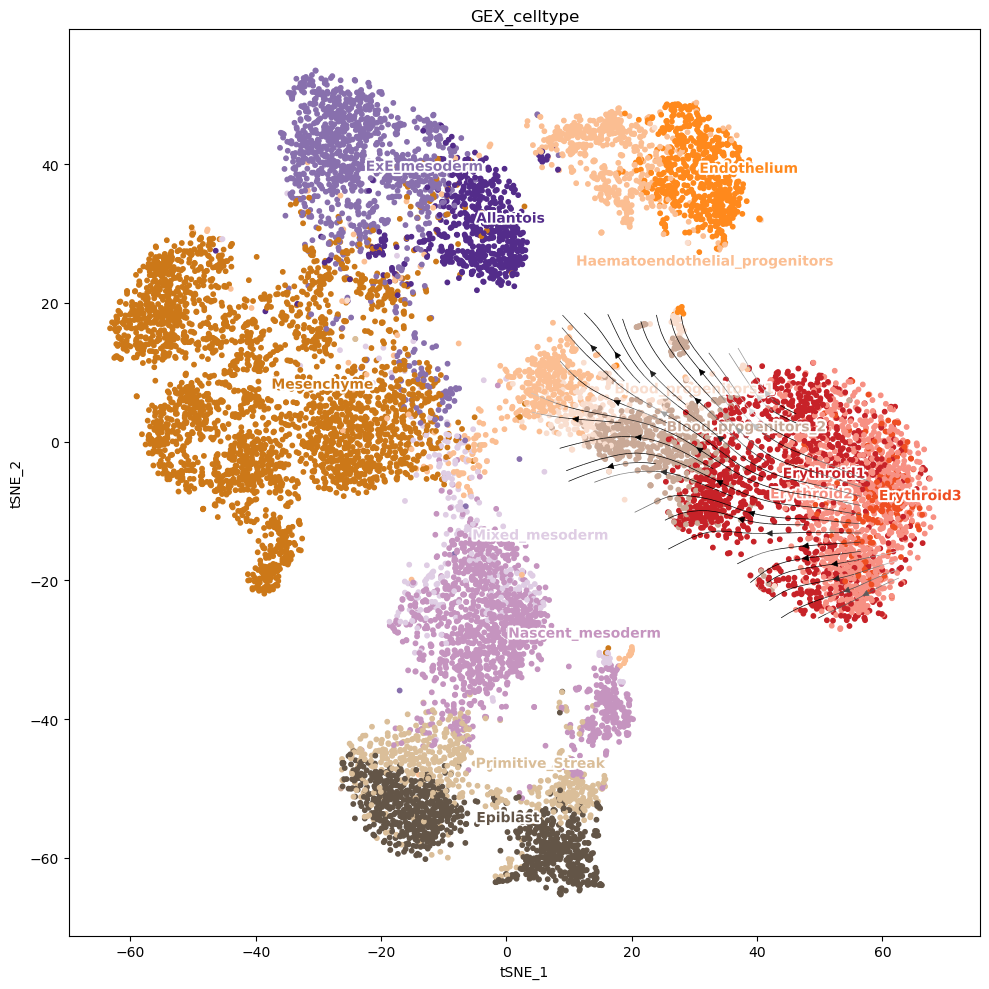

In [106]:
# Now in UMAP embedding

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
_ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_tSNE',
        n_cpu = 30,
        perturbation = {'Stat3': 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_celltype',
        color_dictionary = {'GEX_celltype': color_dict_line},
        genes_to_use = hvg,
        figsize = (10, 10))

In [109]:
# from scenicplus.simulation import * 
# regressor_hvg = train_gene_expression_models(
#         scplus_obj,
#         eRegulon_metadata_key = 'eRegulon_metadata_filtered',
#         genes = hvg)

### GRN Velocity!